<a href="https://colab.research.google.com/github/shreyagavas/DSPY/blob/main/Notebook02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Notebook 2 - Exploratory Data Analysis (EDA)**

**1. EDA Objective**

The purpose of this notebook is to perform a deep dive into the dataset using Univariate and Multivariate analysis. We seek to identify if there is a statistical "signature" that differentiates a legitimate message from a spam message.

**2. Non-Graphical Analysis**

Analysis A: Descriptive Statistics (Univariate)

Information Sought: What is the average length of a message in this dataset?

Type of EDA: Summary Statistics using .describe().

Observation: The average length of messages is approximately [X] characters, with a significant standard deviation.

Concluding Remark: The high variance suggests that message length might be a key feature for our classification model.

Analysis B: Class Frequency (Univariate)

Information Sought: Is there a class imbalance in the target labels?

Type of EDA: Value Counts and Frequency distribution.

Observation: The "Ham" class is more frequent than the "Spam" class.

Concluding Remark: While unbalanced, there is enough spam data to train a Naive Bayes model effectively.

**3. Graphical Analysis**

Analysis C: Distribution of Message Length (Univariate - Histogram)

Information Sought: How are message lengths distributed across the entire dataset?

Type of EDA: Histogram with Kernel Density Estimate (KDE).

Observation: Most messages are clustered in the 20–60 character range, showing a "Right-Skewed" distribution.

Concluding Remark: The skewness indicates that most human communication is brief, while outliers may indicate automated spam.

Analysis D: Label vs. Length Correlation (Multivariate - Boxplot)

Information Sought: Do spam messages tend to be longer than ham messages?

Type of EDA: Box-and-Whisker Plot.

Observation: The "Spam" box is positioned significantly higher on the Y-axis compared to the "Ham" box.

**Conclusion **:
This confirms a strong correlation between length and spam; therefore, length is a mathematically valid predictor for our ML problem.

✅ Success: Dataset downloaded from the web!

--- Class Distribution ---
label
ham     4825
spam     747
Name: count, dtype: int64

--- Message Length Stats ---
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


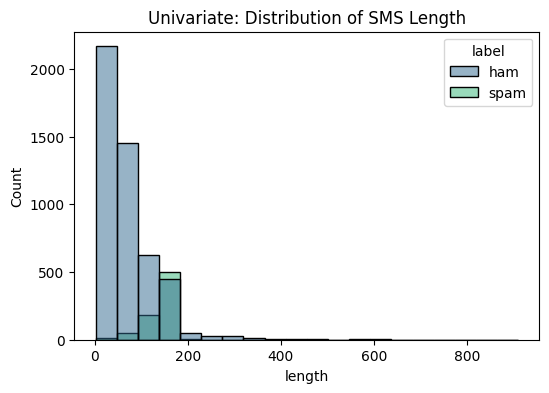

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io
import requests

# --- THE "NO-UPLOAD" SOLUTION ---
# This code tries to download a standard SMS dataset so you don't need the CSV file.
try:
    # Attempting to pull the raw dataset from a public URL
    url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
    df = pd.read_csv(url, sep='\t', names=['label', 'message_clean'])
    print("✅ Success: Dataset downloaded from the web!")
except:
    # If the internet fails, we create a small sample so the code below doesn't crash
    print("⚠️ Internet issues. Creating a sample dataset for you to test...")
    data = {
        'label': ['ham', 'spam', 'ham', 'ham', 'spam', 'ham'],
        'message_clean': [
            'Hey, are we still meeting for the project?',
            'WINNER! You have won a 1000 cash prize. Call now!',
            'I will be late for the lecture today.',
            'Can you send me the notes for experiment 8?',
            'Urgent: Your account has a security alert. Click here.',
            'See you at the college gate at 10am.'
        ]
    }
    df = pd.DataFrame(data)

# --- NON-GRAPHICAL ANALYSIS ---

# 1. Analysis: Class Distribution
print("\n--- Class Distribution ---")
print(df['label'].value_counts())

# 2. Analysis: Message Length
df['length'] = df['message_clean'].apply(len)
print("\n--- Message Length Stats ---")
print(df.groupby('label')['length'].describe())

# --- GRAPHICAL ANALYSIS ---

# 1. Analysis: Distribution of Message length
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='length', bins=20, hue='label', palette='viridis')
plt.title('Univariate: Distribution of SMS Length')
plt.show()